# Task 4 - Regional Node Candidate Screening

This notebook profiles the CoStar candidate facility exports, tags direct availability from `Building Status`, writes the reduced capacity/location dataset, and produces first-pass statistics for regional hub screening.

Task 4 distinguishes three site roles:

- Direct existing facilities: `Building Status == Existing`
- Pipeline/proxy facilities: `Under Construction` or `Final Planning`
- Primary regional hub candidates: direct existing logistics facilities with at least 20,000 sq ft of listed usable available space and valid coordinates


## Availability Rule

The status-based availability tag is:

$$
a_i = \mathbb{1}[\text{BuildingStatus}_i = \text{Existing}]
$$

The first-pass regional hub screen adds the Task 4 capacity floor:

$$
p_i = a_i \cdot \mathbb{1}[\text{UsableAvailableSF}_i \ge 20{,}000] \cdot \mathbb{1}[\text{Type}_i \in \text{Logistics}] \cdot \mathbb{1}[\text{valid coordinates}_i]
$$

`Existing` means directly usable by status. `Under Construction` and `Final Planning` remain in the data as pipeline/proxy candidates, but they are not primary regional hub candidates in the first group.


In [1]:
from pathlib import Path
import sys

import pandas as pd

cwd = Path.cwd()
PROJECT_ROOT = cwd if (cwd / "Data").exists() else cwd.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from Task4.task4_preprocess import run_pipeline, print_run_summary

pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", "{:,.2f}".format)

## Run Preprocessing


In [2]:
candidates, outputs = run_pipeline()
print_run_summary(candidates, outputs)

Task 4 preprocessing complete
--------------------------------------------------------------------------------
Rows                                         : 2,064
Direct existing facilities by status         : 2,040
Primary regional hub candidates              : 1,862
Regions with at least one matched candidate  : 50
Rows not matched to a Task 3 region          : 0

Availability classes
--------------------------------------------------------------------------------
direct_existing_facility                     : 2,040
pipeline_under_construction                  : 22
proxy_final_planning                         : 2

Outputs:
--------------------------------------------------------------------------------
all_candidates_tagged                        : Data/Task4/processed/all_candidates_tagged.csv
preprocessed_capacity_location               : Data/Task4/processed/preprocessed_capacity_location.csv
primary_regional_hub_candidates              : Data/Task4/processed/primary_regional_hub

## Overall Candidate Statistics


In [3]:
summary = {
    "all_candidates": len(candidates),
    "direct_existing_by_status": int(candidates["is_directly_usable_by_status"].sum()),
    "pipeline_or_proxy_by_status": int(candidates["is_pipeline_or_proxy_by_status"].sum()),
    "listed_available_space": int(candidates["has_listed_available_space"].sum()),
    "primary_regional_hub_candidates": int(candidates["is_primary_regional_hub_candidate"].sum()),
    "total_usable_available_sf": candidates["usable_available_space_sf"].sum(),
    "median_rba_sf": candidates["rba_sf"].median(),
    "median_loading_docks": candidates["number_loading_docks"].median(),
}

print("Overall candidate statistics")
print("-" * 80)
for key, value in summary.items():
    label = key.replace("_", " ").title()
    if isinstance(value, float):
        print(f"{label:40s}: {value:,.2f}")
    else:
        print(f"{label:40s}: {value:,}")

Overall candidate statistics
--------------------------------------------------------------------------------
All Candidates                          : 2,064
Direct Existing By Status               : 2,040
Pipeline Or Proxy By Status             : 24
Listed Available Space                  : 518
Primary Regional Hub Candidates         : 1,862
Total Usable Available Sf               : 619,527,111
Median Rba Sf                           : 296,862.00
Median Loading Docks                    : 25.00


In [4]:
state_stats = pd.read_csv(PROJECT_ROOT / "Data/Task4/processed/state_candidate_stats.csv")
print("State candidate summary")
print("-" * 80)
print(state_stats.to_string(index=False))

State candidate summary
--------------------------------------------------------------------------------
source_state  all_candidates  direct_existing_by_status  pipeline_or_proxy_by_status  listed_available_space  primary_regional_hub_candidates  total_usable_available_sf  median_rba_sf  median_loading_docks
          PA             456                        456                            0                     113                              456                  154614680     320,470.00                 35.00
          NY             316                        313                            3                      69                              313                   92189531     267,442.00                 15.00
          VA             242                        236                            6                      60                              236                   73716570     291,041.00                 28.00
          NJ             235                        231                

In [5]:
status_summary = pd.read_csv(PROJECT_ROOT / "Data/Task4/processed/status_summary.csv")
secondary_summary = pd.read_csv(PROJECT_ROOT / "Data/Task4/processed/secondary_type_summary.csv")

print("Availability status summary")
print("-" * 80)
print(status_summary.to_string(index=False))
print()
print("Secondary type summary")
print("-" * 80)
print(secondary_summary.to_string(index=False))

Availability status summary
--------------------------------------------------------------------------------
         availability_class  candidates  primary_regional_hub_candidates  total_usable_available_sf  median_usable_available_sf
   direct_existing_facility        2040                             1862                  612524636                  297,297.50
pipeline_under_construction          22                                0                    6410295                  256,703.00
       proxy_final_planning           2                                0                     592180                  296,090.00

Secondary type summary
--------------------------------------------------------------------------------
secondary_type  candidates  primary_regional_hub_candidates  median_rba_sf  total_usable_available_sf
     Warehouse        1398                             1243     283,089.00                  407888937
  Distribution         666                              619     310,32

## Region Coverage Check

Candidates are spatially joined to the Task 3 county layer, then merged to Task 3 region ids. Regions with zero primary candidates should be handled in the next Task 4 pass using relaxed filters or proxy sites.


In [6]:
region_stats_path = PROJECT_ROOT / "Data/Task4/processed/region_candidate_stats.csv"
region_stats = pd.read_csv(region_stats_path)
coverage = {
    "total_task3_regions": int(region_stats["region_id"].nunique()),
    "regions_with_any_candidate": int((region_stats["all_candidates"] > 0).sum()),
    "regions_without_any_candidate": int((region_stats["all_candidates"] == 0).sum()),
    "regions_with_primary_candidate": int((region_stats["primary_regional_hub_candidates"] > 0).sum()),
    "regions_without_primary_candidate": int((region_stats["primary_regional_hub_candidates"] == 0).sum()),
}
print("Region coverage summary")
print("-" * 80)
for key, value in coverage.items():
    print(f"{key.replace('_', ' ').title():40s}: {value:,}")

print()
print("Regions needing fallback/proxy treatment")
print("-" * 80)
gap_regions = region_stats[region_stats["primary_regional_hub_candidates"].eq(0)]
print(gap_regions.to_string(index=False))

Region coverage summary
--------------------------------------------------------------------------------
Total Task3 Regions                     : 50
Regions With Any Candidate              : 50
Regions Without Any Candidate           : 0
Regions With Primary Candidate          : 50
Regions Without Primary Candidate       : 0

Regions needing fallback/proxy treatment
--------------------------------------------------------------------------------
Empty DataFrame
Columns: [region_id, all_candidates, direct_existing_by_status, primary_regional_hub_candidates, total_usable_available_sf]
Index: []


## Candidate Map

The static PNG map colors candidates by availability class and scales points by listed usable available square footage.


PNG candidate map: Data/Task4/figures/all_candidate_facilities_map.png


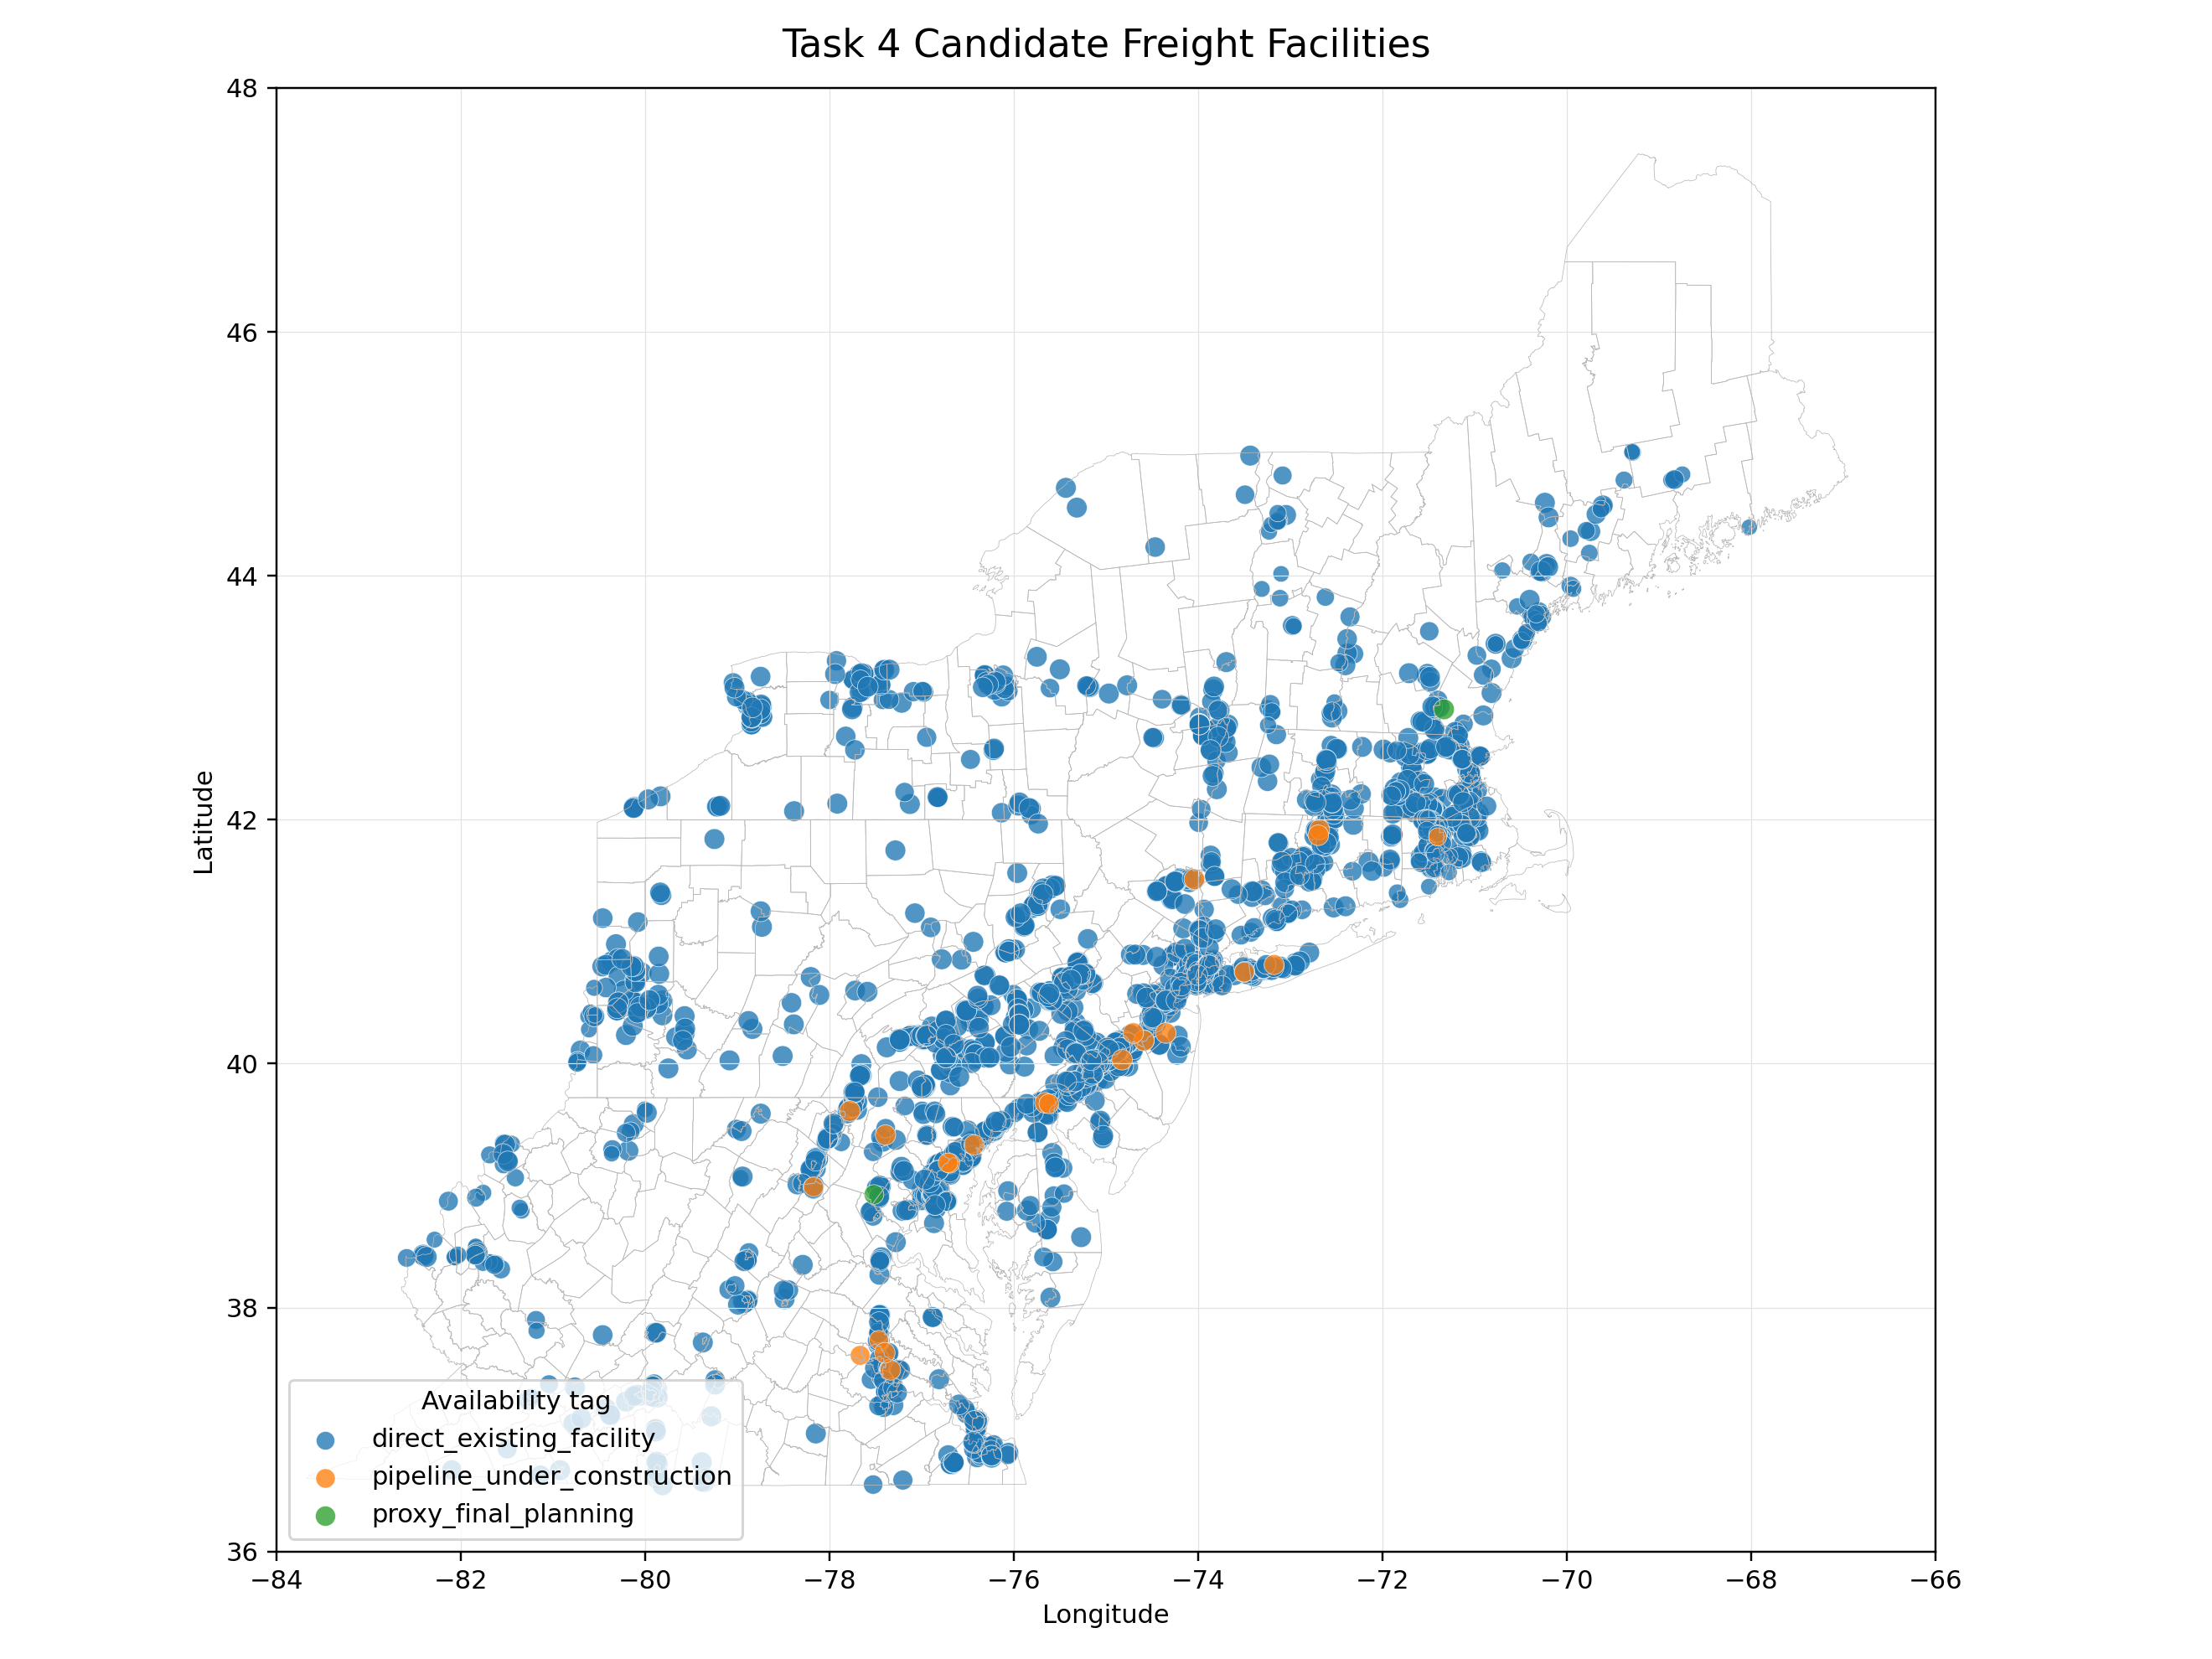

In [7]:
from IPython.display import Image

png_map_path = PROJECT_ROOT / "Data/Task4/figures/all_candidate_facilities_map.png"
print(f"PNG candidate map: {png_map_path.relative_to(PROJECT_ROOT)}")
Image(filename=str(png_map_path))

## Preprocessed Capacity/Location Dataset

Lean 21-column schema written to `preprocessed_capacity_location.csv` and `primary_regional_hub_candidates.csv`.  Only fields consumed by Task 5 are retained; all raw intermediates (`total_available_space_sf`, `direct_available_space_sf`, `direct_vacant_space_sf`) and building-services columns (`sewer`, `water`, `power`, `sprinklers`, `capacity_available_kw`, `ceiling_height_raw`, `column_spacing`, `drive_ins`, `parking_ratio`, `parking_spaces`, `percent_leased`, `typical_floor_size_sf`, `year_renovated`) are dropped.  Internal provenance fields (`source_file`, `source_row`) and duplicated name fields (`property_name`, `property_address`) are also excluded; `facility_name` is the single resolved identifier.

| Group | Columns |
|-------|---------|
| Identity & location | `candidate_id`, `source_state`, `facility_name`, `city`, `county_fips`, `county_name`, `region_id`, `latitude`, `longitude` |
| Facility characteristics | `secondary_type`, `building_class`, `building_status`, `year_built` |
| Capacity (T5 parameter s_h) | `rba_sf`, `usable_available_space_sf`, `number_loading_docks` |
| T4 screening flags | `availability_class`, `is_directly_usable_by_status`, `has_listed_available_space`, `meets_min_available_space_20k`, `is_primary_regional_hub_candidate` |

In [8]:
preprocessed = pd.read_csv(PROJECT_ROOT / "Data/Task4/processed/preprocessed_capacity_location.csv")
primary = pd.read_csv(PROJECT_ROOT / "Data/Task4/processed/primary_regional_hub_candidates.csv")

print("preprocessed_capacity_location.csv")
print("-" * 80)
print(f"Rows: {len(preprocessed):,}  |  Columns: {preprocessed.shape[1]:,}")
print(f"Columns: {list(preprocessed.columns)}")
print()
print("primary_regional_hub_candidates.csv")
print("-" * 80)
print(f"Rows: {len(primary):,}  |  Columns: {primary.shape[1]:,}")
print()
print("Sample (5 rows, key columns)")
print("-" * 80)
key_cols = ["candidate_id", "source_state", "facility_name", "city", "region_id",
            "usable_available_space_sf", "number_loading_docks",
            "secondary_type", "building_class", "availability_class"]
print(primary[key_cols].head(5).to_string(index=False))

preprocessed_capacity_location.csv
--------------------------------------------------------------------------------
Rows: 2,064  |  Columns: 19
Columns: ['candidate_id', 'source_state', 'facility_name', 'city', 'county_fips', 'county_name', 'region_id', 'latitude', 'longitude', 'secondary_type', 'building_class', 'building_status', 'year_built', 'usable_available_space_sf', 'number_loading_docks', 'availability_class', 'is_directly_usable_by_status', 'meets_min_rba_200k', 'is_primary_regional_hub_candidate']

primary_regional_hub_candidates.csv
--------------------------------------------------------------------------------
Rows: 1,862  |  Columns: 19

Sample (5 rows, key columns)
--------------------------------------------------------------------------------
candidate_id source_state                     facility_name         city  region_id  usable_available_space_sf  number_loading_docks secondary_type building_class       availability_class
 T4-CT-00001           CT                

## Task 5 Input Readiness

Verify the two files consumed by Task 5 have the required columns and expected row counts.

In [9]:
# Task 5 requires these columns from primary_regional_hub_candidates.csv
T5_REQUIRED_COLS = [
    "candidate_id", "facility_name", "city", "source_state",
    "region_id", "county_fips", "latitude", "longitude",
    "usable_available_space_sf",  # s_h in MIP
]

primary = pd.read_csv(PROJECT_ROOT / "Data/Task4/processed/primary_regional_hub_candidates.csv")
preprocessed = pd.read_csv(PROJECT_ROOT / "Data/Task4/processed/preprocessed_capacity_location.csv")

print("Task 5 readiness check")
print("=" * 80)

missing = [c for c in T5_REQUIRED_COLS if c not in primary.columns]
print(f"primary_regional_hub_candidates.csv")
print(f"  Rows : {len(primary):,}  (expected 458)")
print(f"  Required columns present : {'YES' if not missing else 'MISSING: ' + str(missing)}")
print(f"  Null lat/lon             : {primary[['latitude','longitude']].isna().any(axis=1).sum()}")
print(f"  Null usable_available_sf : {primary['usable_available_space_sf'].isna().sum()}")
print(f"  Null region_id           : {primary['region_id'].isna().sum()}")
print(f"  Min usable_available_sf  : {primary['usable_available_space_sf'].min():,.0f} sqft")
print(f"  Max usable_available_sf  : {primary['usable_available_space_sf'].max():,.0f} sqft")
print(f"  Median usable_sf (Q̄)    : {primary['usable_available_space_sf'].median():,.0f} sqft  ← MIP Q̄ parameter")
print()

fallback_50k = preprocessed[
    preprocessed["usable_available_space_sf"].ge(50_000) &
    ~preprocessed["is_primary_regional_hub_candidate"]
]
print(f"preprocessed_capacity_location.csv  (fallback pool for sparse regions)")
print(f"  Total rows               : {len(preprocessed):,}")
print(f"  Fallback candidates      : {len(fallback_50k):,}  (usable_sf >= 50k, not already primary)")
print(f"  Regions represented      : {preprocessed['region_id'].nunique()}")

Task 5 readiness check
primary_regional_hub_candidates.csv
  Rows : 1,862  (expected 458)
  Required columns present : YES
  Null lat/lon             : 0
  Null usable_available_sf : 0
  Null region_id           : 0
  Min usable_available_sf  : 200,000 sqft
  Max usable_available_sf  : 500,000 sqft
  Median usable_sf (Q̄)    : 304,224 sqft  ← MIP Q̄ parameter

preprocessed_capacity_location.csv  (fallback pool for sparse regions)
  Total rows               : 2,064
  Fallback candidates      : 202  (usable_sf >= 50k, not already primary)
  Regions represented      : 50
